# Traffic sign classification with LeNet
Use LeNet CNN to recognize traffic sign images

https://en.wikipedia.org/wiki/LeNet

![Alt text](../assets/LeNet-5_architecture.png "LeNet")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import pickle
import zipfile
import random
from sklearn.utils import shuffle

## Download dataset
Haque, Md. Rezwanul (2018). traffic-signs-data.zip. figshare. Dataset. https://doi.org/10.6084/m9.figshare.6112562.v1


In [2]:
url = "https://figshare.com/ndownloader/files/11016233"
filename = "traffic-signs-data.zip"
destiny_folder = "../datasets"

try:
    os.makedirs(destiny_folder, exist_ok=True)
    print(f"Folder '{destiny_folder}' created or already exists.")

    # Download
    print(f"Starting downloading from '{url}' file '{filename}'...")
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Lança uma exceção para erros HTTP

    with open(filename, "wb") as arquivo_zip:
        for chunk in response.iter_content(chunk_size=8192):
            arquivo_zip.write(chunk)
    print(f"Download '{filename}' finished.")

    # Unzip
    print(f"Unzip '{filename}' to folder '{destiny_folder}'...")
    with zipfile.ZipFile(filename, "r") as zip_ref:
        zip_ref.extractall(destiny_folder)
    print(f"Unzip to '{destiny_folder}' finished.")

    # Remove zip file
    os.remove(filename)
    print(f"File '{filename}' removed.")

except requests.exceptions.RequestException as e:
    print(f"Download error: {e}")
except zipfile.BadZipFile:
    print(f"Error: The file '{filename}' is invalid.")
except OSError as e:
    print(f"Could not create the folder '{destiny_folder}': {e}")
except Exception as e:
    print(f"Error: {e}")

Folder '../datasets' created or already exists.
Starting downloading from 'https://figshare.com/ndownloader/files/11016233' file 'traffic-signs-data.zip'...
Download 'traffic-signs-data.zip' finished.
Unzip 'traffic-signs-data.zip' to folder '../datasets'...
Unzip to '../datasets' finished.
File 'traffic-signs-data.zip' removed.


## Load Model

In [3]:
with open('../datasets/train.p', mode='rb') as training_data:
  train = pickle.load(training_data)

with open('../datasets/test.p', mode='rb') as testing_data:
  test = pickle.load(testing_data)

with open('../datasets/valid.p', mode='rb') as validation_data:
  valid = pickle.load(validation_data)

In [4]:
X_train, y_train = train['features'], train['labels']
X_test, y_test = test['features'], test['labels']
X_validation, y_validation = valid['features'], valid['labels']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(34799, 32, 32, 3) (34799,) (12630, 32, 32, 3) (12630,)


## Data visualization

np.uint8(12)

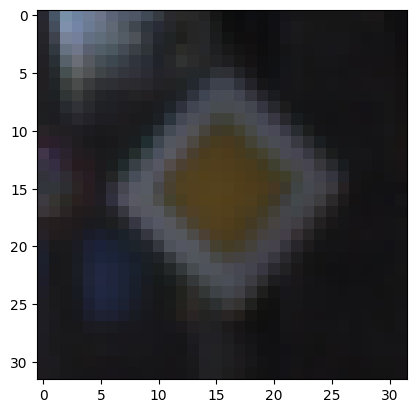

In [5]:
i = random.randint(0, 34799)
plt.imshow(X_train[i])
y_train[i]


## Data preparation

Transform images into gray scale colors (1 color channel)

In [6]:
X_train, y_train = shuffle(X_train, y_train)
X_train_gray = np.sum(X_train / 3, axis = 3, keepdims=True)
X_test_gray = np.sum(X_test / 3, axis = 3, keepdims=True)
X_validation_gray = np.sum(X_validation / 3, axis = 3, keepdims=True)

X_train_gray_norm = (X_train_gray - 128) / 128
X_test_gray_norm = (X_test_gray - 128) / 128
X_validation_gray_norm = (X_validation_gray - 128) / 128

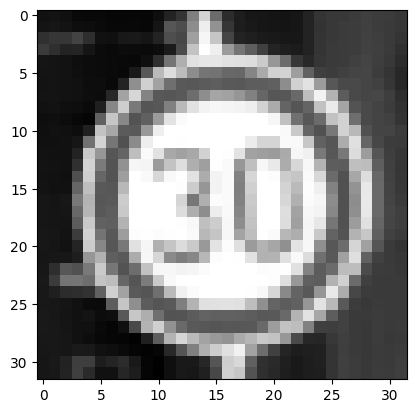

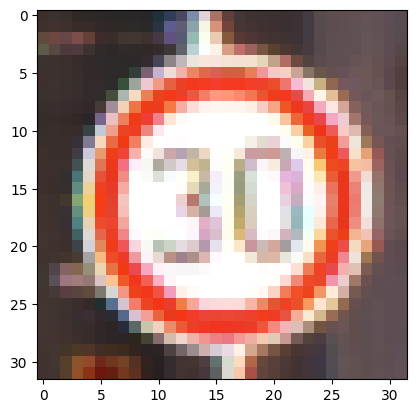

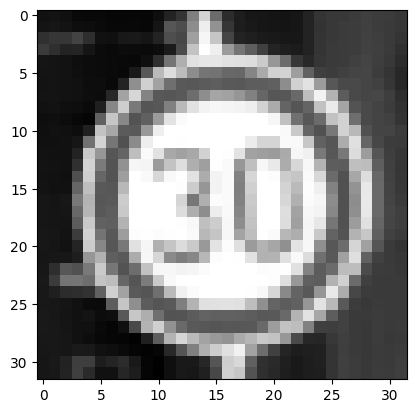

In [7]:
i = 60
plt.imshow(X_train_gray[i].squeeze(), cmap='gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray_norm[i].squeeze(), cmap = 'gray')

## Build LeNet CNN Model

In [8]:
LeNet = models.Sequential()

LeNet.add(layers.Conv2D(6, (5,5), activation = 'relu', input_shape = (32, 32, 1)))
LeNet.add(layers.AveragePooling2D(pool_size=(2)))

LeNet.add(layers.Conv2D(16, (5,5), activation = 'relu'))
LeNet.add(layers.AveragePooling2D(pool_size=(2)))

LeNet.add(layers.Flatten())

LeNet.add(layers.Dense(120, activation='relu'))

LeNet.add(layers.Dense(84, activation='relu'))

LeNet.add(layers.Dense(43, activation='softmax'))

LeNet.summary()

/opt/miniconda3/envs/ai-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         3,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,511 (252.00 KB)

 Trainable params: 64,511 (252.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [9]:
LeNet.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy', 
              metrics = ['accuracy'])

history = LeNet.fit(X_train_gray_norm, y_train,
                    batch_size = 500,
                    epochs = 50,
                    validation_data = (X_validation_gray_norm, y_validation))

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1260 - loss: 3.4085 - val_accuracy: 0.4057 - val_loss: 2.3820
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5266 - loss: 1.7601 - val_accuracy: 0.6585 - val_loss: 1.2549
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7538 - loss: 0.9063 - val_accuracy: 0.7263 - val_loss: 0.9054
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8352 - loss: 0.6203 - val_accuracy: 0.7923 - val_loss: 0.7308
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8736 - loss: 0.4775 - val_accuracy: 0.8152 - val_loss: 0.6517
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9001 - loss: 0.3759 - val_accuracy: 0.8451 - val_loss: 0.5771
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9165 - loss: 0.3343 - val_accuracy: 0.8404 - val_loss: 0.5764
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9269 - loss: 0.2871 - val_accuracy: 0.8474 - v

In [12]:
score = LeNet.evaluate(X_test_gray_norm, y_test)
print('Test Accuracy: {}'.format(score[1]))

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8727 - loss: 1.1032
Test Accuracy: 0.8751385807991028


## Training / Validation Accuracy

/var/folders/lb/48wqmhk57v97300d6q97s2tw0000gn/T/ipykernel_11767/4210073969.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, accuracy, 'b', color = 'r', label='Training Accuracy')


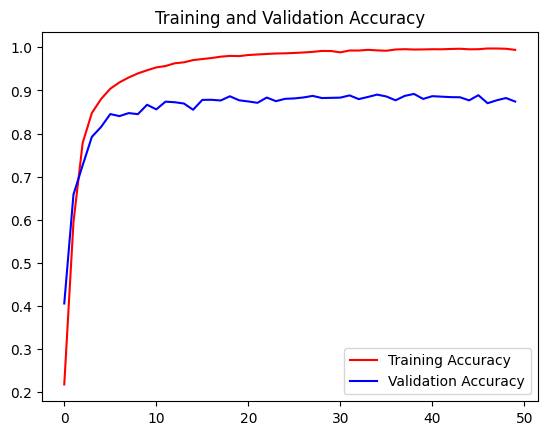

In [13]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'b', color = 'r', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

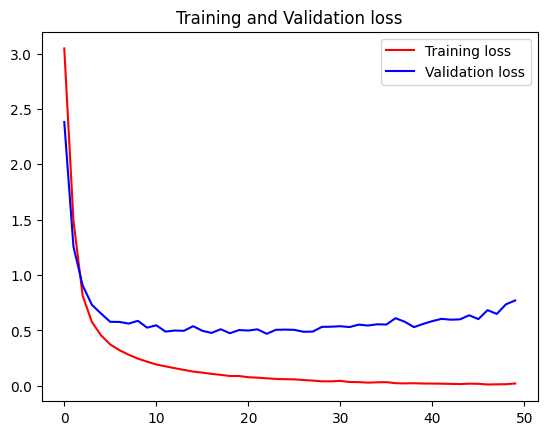

In [14]:
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


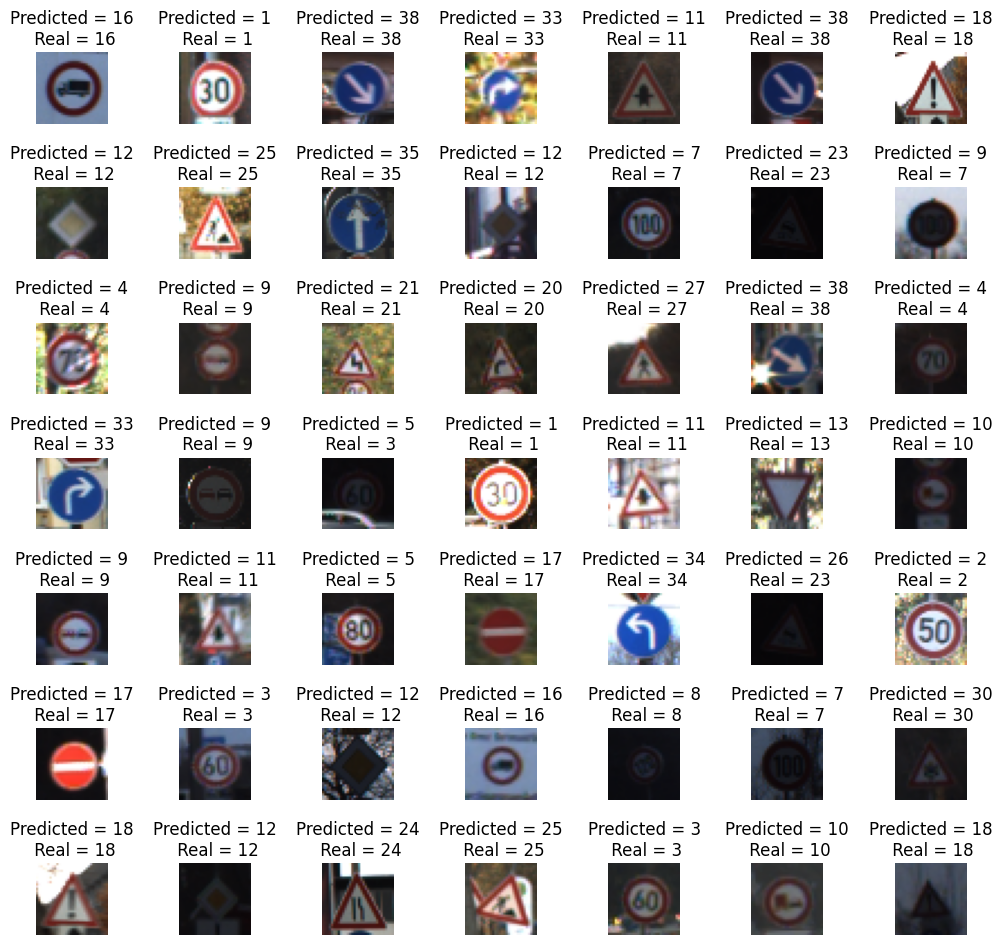

In [15]:
predict_x = LeNet.predict(X_test_gray_norm)
predicted_classes=np.argmax(predict_x,axis=1)
y_true = y_test

L = 7
W = 7

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Predicted = {}\n Real = {}'.format(predicted_classes[i], y_true[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1)  